# Assignment 1: Decision Tree — Student Performance Prediction

Environment ready!
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0
   StudentID  G1  G2  G3      Mjob     Fjob  age address  studytime  failures  \
0          1   6   2   2   teacher  at_home   21   rural          3         1   
1          2  19  11  18    health  teacher   18   rural          1         1   
2          3  14   7  19    health    other   20   urban          1         1   
3          4  10   2   6  services   health   21   urban          3         1   
4          5   7   0  19    health   health   18   rural          4         1   

  schoolsup famsup paid activities nursery higher internet romantic  result  
0        no    yes  yes        yes     yes    yes       no      yes       0  
1        no     no   no         no     yes     no       no       no       1  
2       yes    yes  yes         no      no     no      yes      yes       1  
3       yes     no  yes         no     yes     no       no       no       0  
4        no     no  yes         no     yes    yes      ye

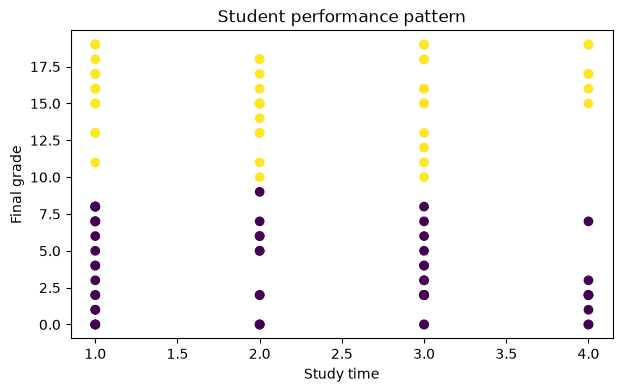

X shape: (100, 4)
y shape: (100,)
Training rows: 80
Testing rows : 20
Model trained!
Accuracy: 0.6
Confusion Matrix:
[[7 4]
 [4 5]]
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64        11
           1       0.56      0.56      0.56         9

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



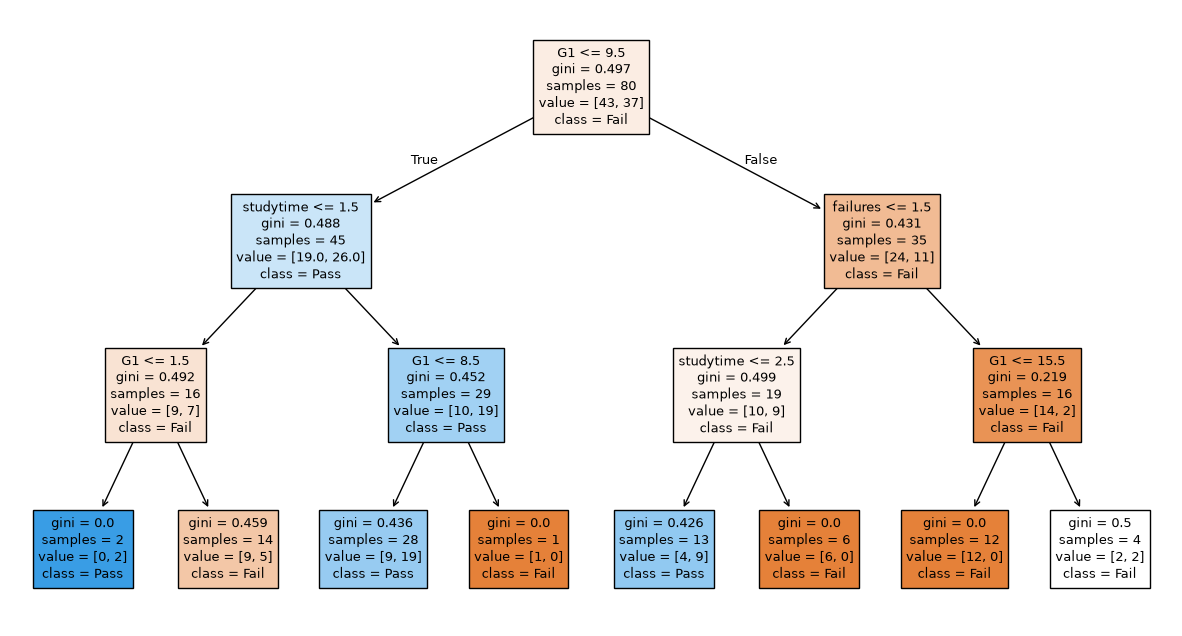

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

df = pd.read_csv("student_performance.csv")

df["result"] = np.where(df["G3"] >= 10, 1, 0)

print(df.head())

print(
    df.groupby("result")[["G1", "G2", "studytime", "failures"]].mean()
)

plt.figure(figsize=(7,4))
plt.scatter(df["studytime"], df["G3"], c=df["result"])
plt.xlabel("Study time")
plt.ylabel("Final grade")
plt.title("Student performance pattern")
plt.show()

X = df[["G1", "G2", "studytime", "failures"]]
y = df["result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(15,8))
plot_tree(
    model,
    feature_names=["G1", "G2", "studytime", "failures"],
    class_names=["Fail", "Pass"],
    filled=True
)
plt.show()

In [7]:
print("Model trained:", hasattr(model, "tree_"))

Model trained: True


In [8]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 0 1 0 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1]


In [9]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Input:")
print(sample)

print("Predicted result:", "Pass" if prediction[0] == 1 else "Fail")
print("Actual result:", "Pass" if y_test.iloc[0] == 1 else "Fail")

Input:
    G1  G2  studytime  failures
36  17   5          1         1
Predicted result: Pass
Actual result: Pass


In [10]:
sample = X_test.iloc[:10]

predictions = model.predict(sample)

for i in range(len(sample)):
    print("Student", i + 1)
    print("Input:")
    print(sample.iloc[i])
    print("Predicted result:", "Pass" if predictions[i] == 1 else "Fail")
    print("Actual result:", "Pass" if y_test.iloc[i] == 1 else "Fail")
    print("-" * 30)

Student 1
Input:
G1           17
G2            5
studytime     1
failures      1
Name: 36, dtype: int64
Predicted result: Pass
Actual result: Pass
------------------------------
Student 2
Input:
G1           11
G2           12
studytime     3
failures      1
Name: 18, dtype: int64
Predicted result: Fail
Actual result: Pass
------------------------------
Student 3
Input:
G1           12
G2           16
studytime     2
failures      2
Name: 71, dtype: int64
Predicted result: Fail
Actual result: Fail
------------------------------
Student 4
Input:
G1            3
G2           16
studytime     4
failures      0
Name: 60, dtype: int64
Predicted result: Pass
Actual result: Pass
------------------------------
Student 5
Input:
G1           2
G2           4
studytime    1
failures     3
Name: 11, dtype: int64
Predicted result: Fail
Actual result: Fail
------------------------------
Student 6
Input:
G1           19
G2           12
studytime     3
failures      1
Name: 26, dtype: int64
Predicted 

In [11]:
sample = X

predictions = model.predict(sample)

for i in range(len(sample)):
    print("Student", i + 1)
    print("Input:")
    print(sample.iloc[i])
    print("Predicted result:", "Pass" if predictions[i] == 1 else "Fail")
    print("Actual result:", "Pass" if y.iloc[i] == 1 else "Fail")
    print("-" * 30)

Student 1
Input:
G1           6
G2           2
studytime    3
failures     1
Name: 0, dtype: int64
Predicted result: Pass
Actual result: Fail
------------------------------
Student 2
Input:
G1           19
G2           11
studytime     1
failures      1
Name: 1, dtype: int64
Predicted result: Pass
Actual result: Pass
------------------------------
Student 3
Input:
G1           14
G2            7
studytime     1
failures      1
Name: 2, dtype: int64
Predicted result: Pass
Actual result: Pass
------------------------------
Student 4
Input:
G1           10
G2            2
studytime     3
failures      1
Name: 3, dtype: int64
Predicted result: Fail
Actual result: Fail
------------------------------
Student 5
Input:
G1           7
G2           0
studytime    4
failures     1
Name: 4, dtype: int64
Predicted result: Pass
Actual result: Pass
------------------------------
Student 6
Input:
G1           6
G2           2
studytime    1
failures     1
Name: 5, dtype: int64
Predicted result: Fail
A

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
sample = X_test

predictions = model.predict(sample)

for i in range(len(sample)):
    print("Student", i + 1)
    print("Input:")
    print(sample.iloc[i])
    print("Predicted result:", "Pass" if predictions[i] == 1 else "Fail")
    print("Actual result:", "Pass" if y_test.iloc[i] == 1 else "Fail")
    print("-" * 30)

Student 1
Input:
G1           17
G2            5
studytime     1
failures      1
Name: 36, dtype: int64
Predicted result: Pass
Actual result: Pass
------------------------------
Student 2
Input:
G1           11
G2           12
studytime     3
failures      1
Name: 18, dtype: int64
Predicted result: Fail
Actual result: Pass
------------------------------
Student 3
Input:
G1           12
G2           16
studytime     2
failures      2
Name: 71, dtype: int64
Predicted result: Fail
Actual result: Fail
------------------------------
Student 4
Input:
G1            3
G2           16
studytime     4
failures      0
Name: 60, dtype: int64
Predicted result: Pass
Actual result: Pass
------------------------------
Student 5
Input:
G1           2
G2           4
studytime    1
failures     3
Name: 11, dtype: int64
Predicted result: Fail
Actual result: Fail
------------------------------
Student 6
Input:
G1           19
G2           12
studytime     3
failures      1
Name: 26, dtype: int64
Predicted 

In [14]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6


In [15]:
print("Accuracy:", accuracy * 100, "%")

Accuracy: 60.0 %


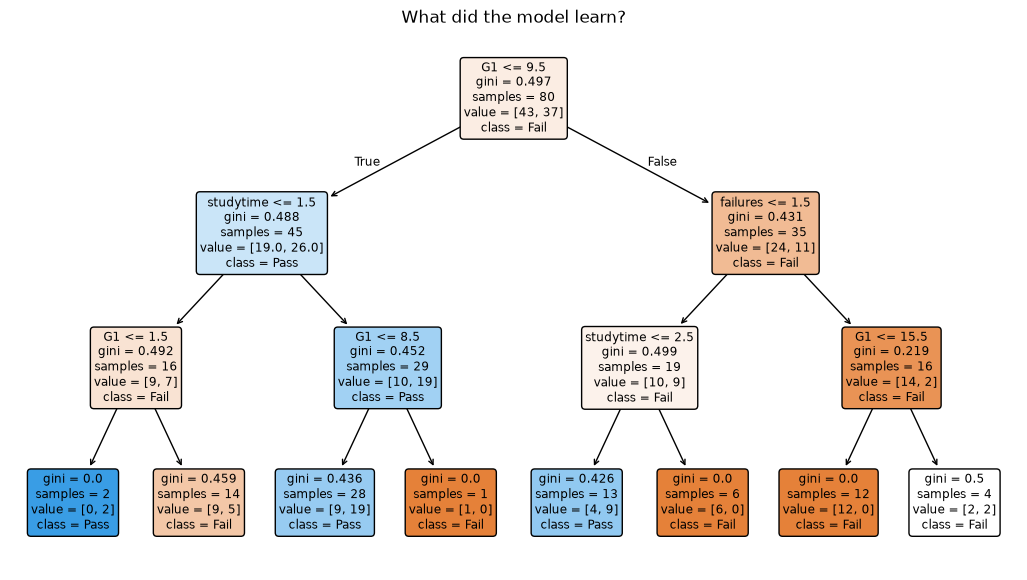

In [17]:
plt.figure(figsize=(13,7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)

plt.title("What did the model learn?")
plt.show()

In [6]:
from sklearn.tree import DecisionTreeClassifier

In [4]:
from sklearn.model_selection import train_test_split

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("student_performance.csv")

print(df.head())

   StudentID  G1  G2  G3      Mjob     Fjob  age address  studytime  failures  \
0          1   6   2   2   teacher  at_home   21   rural          3         1   
1          2  19  11  18    health  teacher   18   rural          1         1   
2          3  14   7  19    health    other   20   urban          1         1   
3          4  10   2   6  services   health   21   urban          3         1   
4          5   7   0  19    health   health   18   rural          4         1   

  schoolsup famsup paid activities nursery higher internet romantic  
0        no    yes  yes        yes     yes    yes       no      yes  
1        no     no   no         no     yes     no       no       no  
2       yes    yes  yes         no      no     no      yes      yes  
3       yes     no  yes         no     yes     no       no       no  
4        no     no  yes         no     yes    yes      yes       no  


In [8]:
import numpy as np

df["result"] = np.where(df["G3"] >= 10, 1, 0)

In [9]:
X = df[["G1", "G2", "studytime", "failures"]]
y = df["result"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.tree import DecisionTreeClassifier

depths = [3, 4, 5]
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    results.append({
        "Max Depth": depth,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Tree Depth": model.get_depth(),
        "Number of Leaves": model.get_n_leaves()
    })

results_df = pd.DataFrame(results)

print(results_df)

   Max Depth  Training Accuracy  Testing Accuracy  Tree Depth  \
0          3               0.75              0.60           3   
1          4               0.80              0.65           4   
2          5               0.85              0.60           5   

   Number of Leaves  
0                 8  
1                12  
2                18  


In [13]:
import matplotlib.pyplot as plt

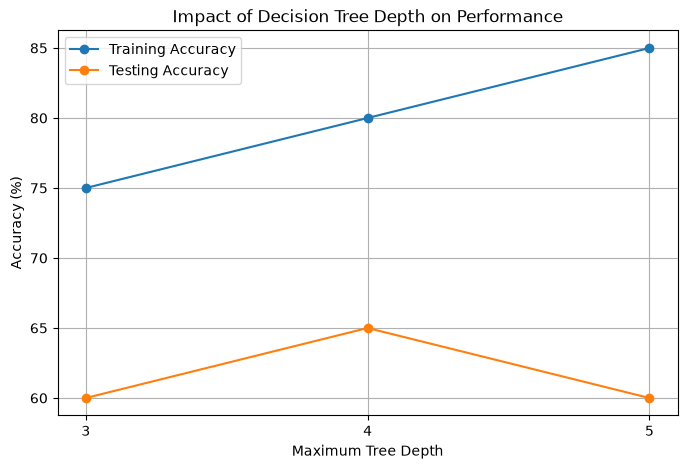

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Max Depth"],
    results_df["Training Accuracy"] * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    results_df["Max Depth"],
    results_df["Testing Accuracy"] * 100,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy (%)")
plt.title("Impact of Decision Tree Depth on Performance")
plt.xticks([3, 4, 5])
plt.legend()
plt.grid(True)
plt.show()

In [20]:
best_depth = results_df.loc[
    results_df["Testing Accuracy"].idxmax(),
    "Max Depth"
]

print("Selected depth:", best_depth)

Selected depth: 4


In [17]:
from sklearn.metrics import accuracy_score

In [18]:
final_model = DecisionTreeClassifier(
    max_depth=int(best_depth),
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.65


In [21]:
from sklearn.tree import plot_tree

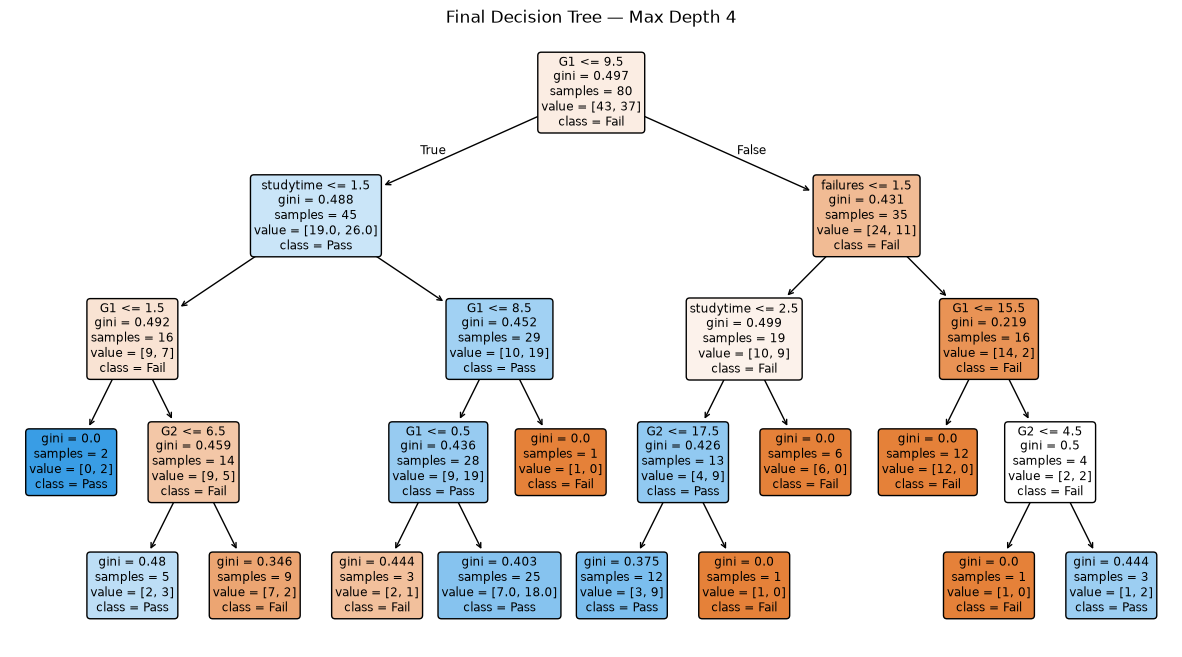

In [22]:
plt.figure(figsize=(15,8))

plot_tree(
    final_model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)

plt.title("Final Decision Tree — Max Depth 4")
plt.show()

### Comparative Analysis

The Decision Tree was trained using maximum depths of 3, 4, and 5.

- At max_depth = 3, the training accuracy was 75% and testing accuracy was 60%.
- At max_depth = 4, the training accuracy increased to 80% and testing accuracy reached 65%.
- At max_depth = 5, the training accuracy increased further to 85%, but testing accuracy decreased to 60%.

The results show that increasing the tree depth improves the model's performance on the training data, but excessive depth can reduce its performance on unseen data. In this experiment, max_depth = 4 was selected for the final model because it achieved the highest testing accuracy of 65% among the tested depths.

# Assignment 2: Linear Regression in Electronics Industry

In [51]:
np.random.seed(42)

voltage = np.arange(5, 51)
current = 0.5 * voltage + np.random.normal(0, 1.5, len(voltage))

electronics_data = pd.DataFrame({
    "Voltage": voltage,
    "Current": current
})

print(electronics_data.head())

   Voltage   Current
0        5  3.245071
1        6  2.792604
2        7  4.471533
3        8  6.284545
4        9  4.148770


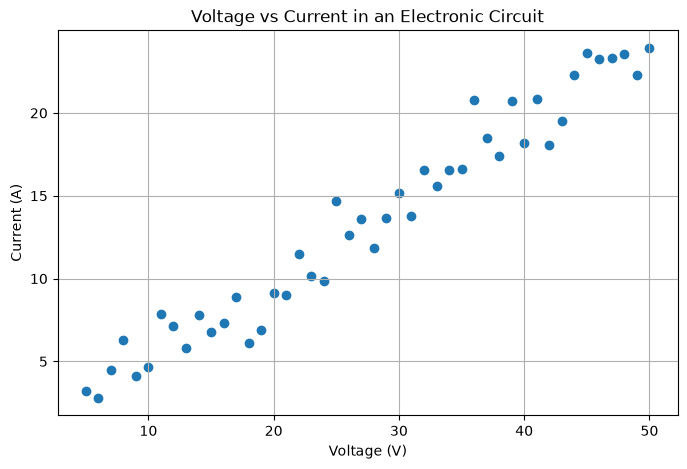

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(electronics_data["Voltage"], electronics_data["Current"])

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Voltage vs Current in an Electronic Circuit")
plt.grid(True)
plt.show()

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
X_e = electronics_data[["Voltage"]]
y_e = electronics_data["Current"]

linear_model = LinearRegression()
linear_model.fit(X_e, y_e)

print("Model trained successfully!")
print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

Model trained successfully!
Slope: 0.47726580941028135
Intercept: 0.28440469168666027


In [29]:
r2_score = linear_model.score(X_e, y_e)

print("R² Score:", r2_score)

R² Score: 0.9574631862077339


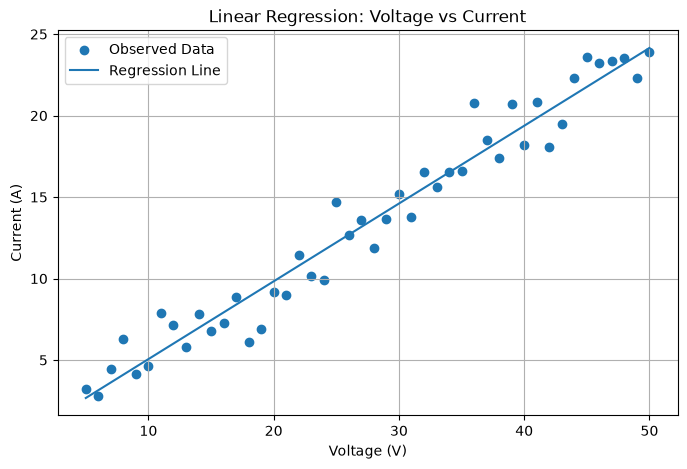

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    electronics_data["Voltage"],
    electronics_data["Current"],
    label="Observed Data"
)

plt.plot(
    electronics_data["Voltage"],
    linear_model.predict(X_e),
    label="Regression Line"
)

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Linear Regression: Voltage vs Current")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
new_voltage = pd.DataFrame({"Voltage": [30]})

predicted_current = linear_model.predict(new_voltage)

print("Predicted current at 30 V:", predicted_current[0], "A")

Predicted current at 30 V: 14.602378973995101 A


### Conclusion

Linear Regression was used to study the relationship between voltage and current in an electronic circuit. The model achieved an R² score of approximately 0.9575, showing a strong relationship between the two variables in this dataset. The model can also be used to estimate current for a given voltage. For example, at 30 V, the predicted current was approximately 14.60 A. This type of analysis can be useful in electronics for studying circuit behaviour and estimating current values.

# Assignment 3: Unsupervised Learning — Exoplanet Clustering

In [32]:
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select%20pl_name,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_orbeccen%20from%20pscomppars&format=csv"

exoplanets = pd.read_csv(url)

print("Number of exoplanets:", len(exoplanets))
print(exoplanets.head())

Number of exoplanets: 6366
         pl_name    pl_rade  pl_masse    pl_orbper  pl_orbsmax  pl_orbeccen
0      HD 2039 b  12.700000       NaN  1120.000000     2.20000         0.71
1      HAT-P-8 b  15.692600  406.8224     3.076340     0.04496         0.00
2        K2-43 b   4.510000       NaN     3.471149     0.03784         0.07
3  Kepler-1753 b   2.226781       NaN    16.004601     0.11790         0.00
4  Kepler-1176 b   2.450000       NaN    24.173858     0.15890         0.00


In [33]:
features = [
    "pl_rade",
    "pl_masse",
    "pl_orbper",
    "pl_orbsmax",
    "pl_orbeccen"
]

exoplanets_clean = exoplanets.dropna(subset=features).copy()

print("Original exoplanets:", len(exoplanets))
print("Usable exoplanets:", len(exoplanets_clean))
print("\nSelected features:")
print(exoplanets_clean[features].describe())

Original exoplanets: 6366
Usable exoplanets: 1928

Selected features:
           pl_rade     pl_masse     pl_orbper   pl_orbsmax  pl_orbeccen
count  1928.000000  1928.000000  1.928000e+03  1928.000000  1928.000000
mean      8.565780   659.673877  5.036228e+03     1.478972     0.113417
std       5.611892  1394.301019  1.382998e+05    15.329644     0.173251
min       0.309800     0.020000  1.797190e-01     0.005626     0.000000
25%       2.609000    10.400000  3.486902e+00     0.045077     0.000000
50%      10.317867   131.449725  7.497281e+00     0.072575     0.039000
75%      12.995105   534.731631  3.170868e+01     0.194250     0.158625
max      25.000000  9344.155166  5.800000e+06   556.000000     0.950000


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(exoplanets_clean[features])

print("Scaled data shape:", X_scaled.shape)
print("First 5 scaled rows:")
print(X_scaled[:5])

Scaled data shape: (1928, 5)
First 5 scaled rows:
[[ 1.27027924 -0.18139345 -0.0364025  -0.09356931 -0.65480878]
 [-1.27722333 -0.47094866 -0.0364198  -0.0956547   0.73082372]
 [ 1.32150521 -0.28171718 -0.03640078 -0.09340357 -0.65480878]
 [-1.16493259 -0.46822257 -0.03636452 -0.09148522 -0.65480878]
 [ 0.35125262 -0.3250388  -0.03640378 -0.09398038 -0.65480878]]


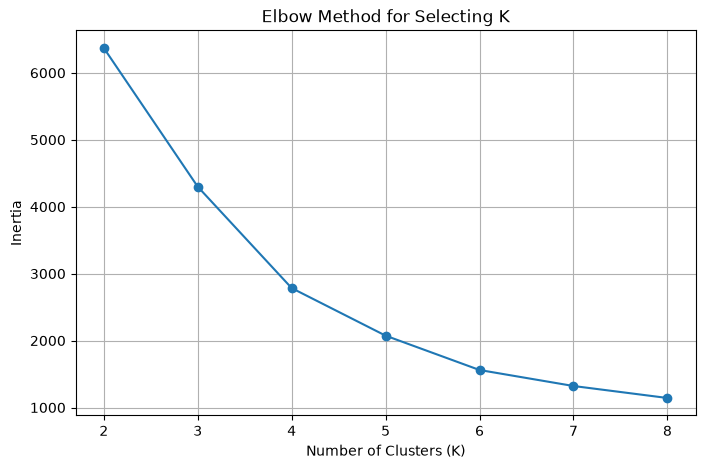

In [35]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")
plt.xticks(range(2, 9))
plt.grid(True)
plt.show()

In [36]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.9521
K = 3: Silhouette Score = 0.4320
K = 4: Silhouette Score = 0.5170
K = 5: Silhouette Score = 0.5453
K = 6: Silhouette Score = 0.5447
K = 7: Silhouette Score = 0.5446
K = 8: Silhouette Score = 0.5446


In [37]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

exoplanets_clean["Cluster"] = cluster_labels

print("K-Means model trained successfully!")
print("\nCluster distribution:")
print(exoplanets_clean["Cluster"].value_counts().sort_index())

K-Means model trained successfully!

Cluster distribution:
Cluster
0    1926
1       2
Name: count, dtype: int64


In [38]:
log_features = [
    "pl_rade",
    "pl_masse",
    "pl_orbper",
    "pl_orbsmax",
    "pl_orbeccen"
]

X_log = np.log1p(exoplanets_clean[log_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Log transformation and scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Log transformation and scaling completed.
Scaled data shape: (1928, 5)


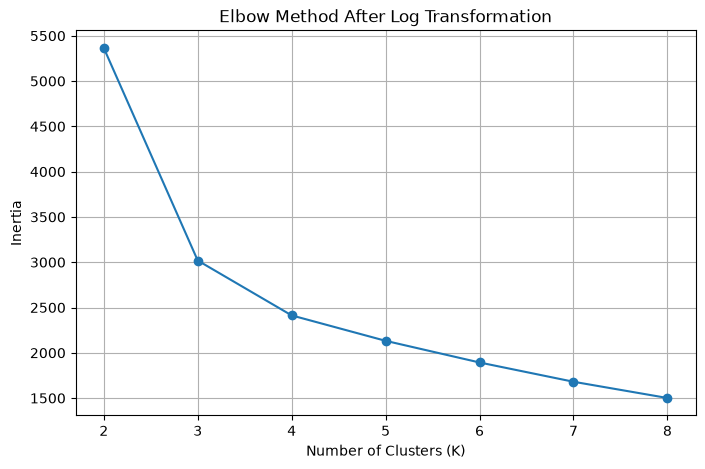

Silhouette Scores:
K = 2: 0.5398
K = 3: 0.4883
K = 4: 0.4891
K = 5: 0.4780
K = 6: 0.4840
K = 7: 0.3707
K = 8: 0.3870


In [39]:
inertia = []
silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method After Log Transformation")
plt.xticks(range(2, 9))
plt.grid(True)
plt.show()

print("Silhouette Scores:")

for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K = {k}: {score:.4f}")

In [40]:
test_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

test_labels = test_kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
print(pd.Series(test_labels).value_counts().sort_index())

Cluster distribution:
0     296
1    1632
Name: count, dtype: int64


In [41]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_scaled)

exoplanets_clean["Cluster"] = final_labels

print("Final K-Means model trained successfully!")
print("\nFinal cluster distribution:")
print(exoplanets_clean["Cluster"].value_counts().sort_index())

Final K-Means model trained successfully!

Final cluster distribution:
Cluster
0     296
1    1632
Name: count, dtype: int64


In [42]:
cluster_summary = exoplanets_clean.groupby("Cluster")[features].median()

print("Median characteristics of each discovered cluster:")
print(cluster_summary)

Median characteristics of each discovered cluster:
           pl_rade     pl_masse    pl_orbper  pl_orbsmax  pl_orbeccen
Cluster                                                              
0        12.600000  1926.199061  2511.823565     3.68900      0.29685
1         6.293853    59.868500     5.401771     0.06035      0.01700


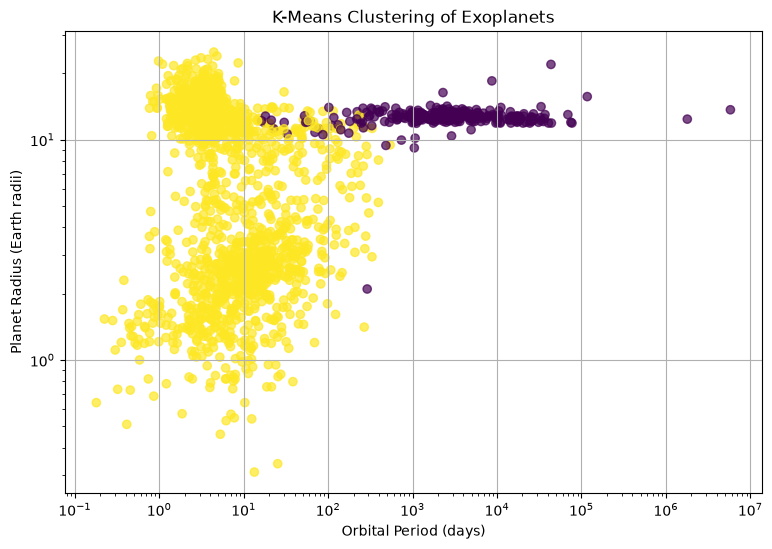

In [43]:
plt.figure(figsize=(9,6))

plt.scatter(
    exoplanets_clean["pl_orbper"],
    exoplanets_clean["pl_rade"],
    c=exoplanets_clean["Cluster"],
    alpha=0.7
)

plt.xlabel("Orbital Period (days)")
plt.ylabel("Planet Radius (Earth radii)")
plt.title("K-Means Clustering of Exoplanets")
plt.xscale("log")
plt.yscale("log")
plt.grid(True)
plt.show()

In [44]:
from sklearn.decomposition import PCA

In [45]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("PCA components:", X_pca.shape[1])
print("Variance explained:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Original features: 5
PCA components: 2
Variance explained: [0.58486663 0.24307535]
Total variance explained: 0.827941977676744


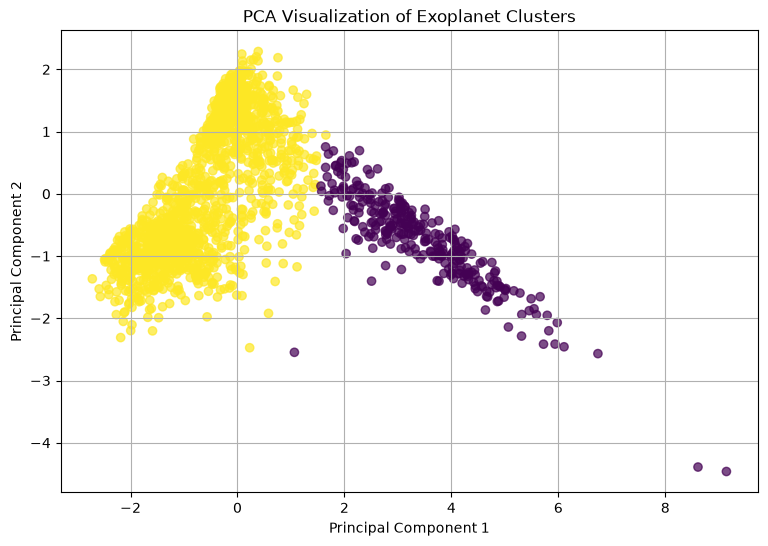

In [46]:
plt.figure(figsize=(9,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=exoplanets_clean["Cluster"],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Exoplanet Clusters")
plt.grid(True)
plt.show()

In [47]:
distances = final_kmeans.transform(X_scaled)

for cluster in range(2):
    closest_indices = np.argsort(distances[:, cluster])[:5]

    print(f"\nCluster {cluster} - Representative Exoplanets:")
    print(
        exoplanets_clean.iloc[closest_indices][
            ["pl_name", "pl_rade", "pl_masse", "pl_orbper", "pl_orbsmax", "pl_orbeccen"]
        ].to_string(index=False)
    )


Cluster 0 - Representative Exoplanets:
    pl_name  pl_rade    pl_masse  pl_orbper  pl_orbsmax  pl_orbeccen
HIP 67851 c     12.7 2204.775659 3128.41000       4.550        0.300
 HIP 8541 b     12.6 2451.728332 1852.14387       3.729        0.360
 HD 74156 c     12.5 2753.983147 2448.48726       3.678        0.377
 HD 27894 d     12.7 2063.659847 5019.54244       5.362        0.343
HD 103891 b     13.2  918.524096 1919.00000       3.270        0.310

Cluster 1 - Representative Exoplanets:
     pl_name  pl_rade  pl_masse  pl_orbper  pl_orbsmax  pl_orbeccen
  TOI-6651 b     5.09     61.00   5.056973      0.0633        0.091
  TOI-4010 d     6.18     38.15  14.708860      0.1130        0.070
Kepler-101 b     5.77     51.10   3.487681      0.0474        0.086
  TOI-3884 b     6.43     32.59   4.544583      0.0361        0.060
  TOI-2498 b     6.06     34.62   3.738252      0.0491        0.089


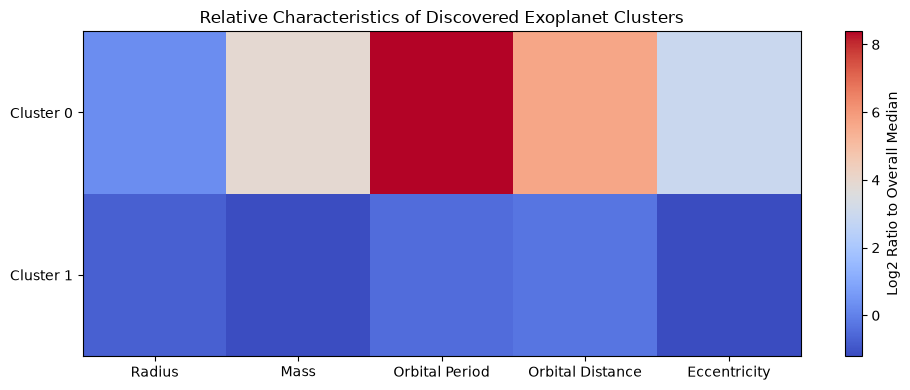

In [50]:
overall_median = exoplanets_clean[features].median()

relative_profile = np.log2(
    cluster_summary / overall_median
)

plt.figure(figsize=(10,4))

plt.imshow(
    relative_profile,
    aspect="auto",
    cmap="coolwarm"
)

plt.xticks(
    range(len(features)),
    ["Radius", "Mass", "Orbital Period", "Orbital Distance", "Eccentricity"]
)

plt.yticks(
    range(2),
    ["Cluster 0", "Cluster 1"]
)

plt.colorbar(label="Log2 Ratio to Overall Median")
plt.title("Relative Characteristics of Discovered Exoplanet Clusters")
plt.tight_layout()
plt.show()

## Final Analysis

K-Means clustering was applied to 1,928 confirmed exoplanets using planet radius, planet mass, orbital period, orbital distance, and orbital eccentricity.

The data was log-transformed and standardized before clustering to reduce the effect of highly skewed astronomical measurements.

The Elbow Method suggested that the major reduction in inertia occurred at lower values of K, while the Silhouette Score reached its highest value of 0.5398 at K = 2. Therefore, K = 2 was selected for the final model.

The final clustering produced two groups containing 296 and 1,632 exoplanets.

Cluster 0 had much larger median values for radius, mass, orbital period, and orbital distance. Its median orbital period was 2511.82 days and median orbital distance was 3.689 AU.

Cluster 1 had smaller median values for these parameters, with a median orbital period of 5.40 days and median orbital distance of 0.06035 AU.

PCA was also used to visualize the five-dimensional feature space in two dimensions. The first two principal components explained 82.79% of the total variance, and the PCA visualization showed clear separation between the discovered clusters.

These results demonstrate how unsupervised learning can identify meaningful patterns in astronomical data without providing predefined class labels to the algorithm.